# 02. Normalizarea denumirii, dozei și formei farmaceutice

**Proiect:** Integrarea probabilistă a registrelor farmaceutice oficiale din Republica Moldova și analiza prețurilor medicamentelor echivalente.
**Autor:** Olesea Popa, grupa SD251M, UTM.

Analiza exploratorie a arătat că lista CNAM se leagă de Nomenclator prin potrivire exactă de text doar pentru 69% din rânduri și că eșecurile nu vin din denumiri, ci din modul diferit în care sursele scriu doza și forma farmaceutică. Acest notebook corespunde pasului de normalizare din pipeline. Scopul lui este să aducă aceeași informație, scrisă diferit, la o formă unică, apoi să măsoare din nou rata de potrivire, ca să știm cât din problemă se rezolvă prin reguli clare și cât rămâne pentru potrivirea probabilistă.

Regulile se află în fișierul src/normalize.py și se aplică identic tuturor surselor, pentru că și Nomenclatorul are inconsecvențe proprii, de exemplu scrie uneori bara oblică cu spații în jurul ei și alteori fără. Coloanele originale nu se modifică. Se adaugă trei coloane noi, denumire_norm, doza_norm și forma_norm, care servesc doar la comparare. De aceea textul lor este scris fără diacritice și în formă prescurtată, de exemplu cuvântul pentru din pulbere pentru soluție este înlocuit cu o bară oblică. Normalizarea nu corectează greșelile de scriere, cum este bicilin în loc de bicillin, pentru că orice astfel de corectură ar fi o ghicire. Acestea rămân în seama pasului următor, potrivirea probabilistă.

## 0. Pregătirea mediului

**Ce căutăm.** Încărcăm bibliotecile și modulele proiectului și citim datele curățate de notebook-ul 01 din folderul data/interim. Apoi aplicăm normalizarea pe Nomenclator, pe Catalog și pe versiunea română a listei CNAM, care este sursa principală.

In [1]:
import sys
from pathlib import Path
import numpy as np                 # calcule numerice
import pandas as pd                # tabele de date
import matplotlib.pyplot as plt    # grafice
import seaborn as sns              # grafice statistice, peste matplotlib

# Rădăcina proiectului: funcționează fie că notebook-ul e pornit din notebooks/, fie din SD_utm/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from clean import key_text, equivalence_key                       # pasul 2: curățarea de bază
from normalize import (normalize_frame, parse_doza, norm_forma,   # pasul 3: normalizarea (acest notebook)
                       norm_doza, norm_denumire, equivalence_key_norm, strip_accents)

FIG = ROOT / "reports" / "figures"
INTERIM = ROOT / "data" / "interim"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight"})
pd.set_option("display.max_colwidth", 70)

# Datele curățate, salvate de notebook-ul 01 (citite ca text, ca să nu pierdem zerourile din coduri)
n  = pd.read_csv(INTERIM / "nomenclator_clean.csv", dtype=str)
c  = pd.read_csv(INTERIM / "catalog_clean.csv", dtype=str)
ro = pd.read_csv(INTERIM / "cnam_ro_clean.csv", dtype=str)
for col in ["pret_mdl", "pret_unitate_mdl", "unitati"]:           # prețurile redevin numere
    c[col] = pd.to_numeric(c[col])

# Normalizarea: adaugă denumire_norm, doza_norm, forma_norm; coloanele originale rămân neschimbate
n, c, ro = normalize_frame(n), normalize_frame(c), normalize_frame(ro)
print("Nomenclator:", n.shape, "| Catalog:", c.shape, "| CNAM RO:", ro.shape)

Nomenclator: (6242, 23) | Catalog: (3719, 31) | CNAM RO: (2167, 18)


**Ce am obținut.** Cele trei surse au același număr de rânduri ca în analiza exploratorie, adică 6.242 de produse în Nomenclator, 3.719 în Catalog și 2.167 de rânduri în lista CNAM. Fiecare tabel are acum câteva coloane în plus, printre care cele trei coloane normalizate, iar restul datelor a rămas neschimbat.

## 1. Forma farmaceutică

**Ce căutăm.** Vrem să știm câte forme scrise în lista CNAM nu există deloc în Nomenclator, înainte și după normalizare. O formă care nu există în Nomenclator face imposibilă potrivirea exactă pentru toate rândurile în care apare.

In [2]:
# Formele CNAM care NU apar ca atare în Nomenclator, înainte (text curățat) și după normalizare
before = ro.forma.notna() & ~key_text(ro.forma).isin(set(key_text(n.forma).dropna()))
after  = ro.forma.notna() & ~ro.forma_norm.isin(set(n.forma_norm.dropna()))

pd.DataFrame({
    "forme distincte în CNAM": [key_text(ro.forma).nunique(), ro.forma_norm.nunique()],
    "forme CNAM absente din Nomenclator": [key_text(ro.forma[before]).nunique(), ro.forma_norm[after].nunique()],
    "rânduri CNAM afectate": [before.sum(), after.sum()],
}, index=["înainte (text curățat)", "după normalizare"]).T

,înainte (text curățat),după normalizare
forme distincte în CNAM,97,67
forme CNAM absente din Nomenclator,43,6
rânduri CNAM afectate,336,11


**Ce am obținut.** Înainte de normalizare, 43 dintre formele scrise în lista CNAM nu apăreau în Nomenclator, iar ele afectau 336 de rânduri. După normalizare au rămas doar 6 astfel de forme, în 11 rânduri. Numărul de forme distincte din lista CNAM a scăzut de la 97 la 67, ceea ce arată că aproape o treime dintre ele erau doar variante de scriere ale acelorași forme.

**Ce căutăm.** Vrem să vedem concret cum a rescris dicționarul formele abreviate, pentru cele mai frecvente dintre ele. Dicționarul conține 19 abrevieri, cum sunt comp. pentru comprimate, sol. pentru soluție și inj. pentru injectabilă, și a fost construit din lista celor 43 de forme găsite mai sus.

In [3]:
# Dicționarul în acțiune: cum a fost rescrisă fiecare formă abreviată (cele mai frecvente)
changed = ro[before]
(changed.assign(forma_cnam=key_text(changed.forma))
        .groupby(["forma_cnam", "forma_norm"]).size().rename("rânduri")
        .sort_values(ascending=False).head(15).reset_index())

,forma_cnam,forma_norm,rânduri
0,comp. film.,comprimate filmate,93
1,caps.,capsule,33
2,pulb./sol. inj./perf.,pulbere/solutie injectabila/perfuzabila,33
3,pulb./susp. orală,pulbere/suspensie orala,16
4,susp. orală,suspensie orala,16
5,sol. inj.,solutie injectabila,15
6,caps. moi,capsule moi,12
7,pulb.+solv./sol. inj.,pulbere+solvent/solutie injectabila,11
8,soluție injectabilă/concentrat pentru soluție perfuzabilă,solutie injectabila/concentrat/solutie perfuzabila,11
9,comp. gastrorez.,comprimate gastrorezistente,8


**Ce am obținut.** Cea mai frecventă abreviere, comp. film., apare în 93 de rânduri și devine comprimate filmate. Urmează caps., în 33 de rânduri, care devine capsule, și pulb./sol. inj./perf., tot în 33 de rânduri, care devine pulbere pentru soluție injectabilă sau perfuzabilă, scrisă în forma de comparare cu bare oblice. Tabelul arată și reguli care nu țin de abrevieri. Forma soluție injectabilă, cartuș din CNAM devine aceeași cu soluție injectabilă în cartuș din Nomenclator, iar două moduri de a scrie soluția injectabilă sau concentratul pentru soluție perfuzabilă, cu și fără spații în jurul barei, ajung la același text.

**Ce căutăm.** Un dicționar scris de mână poate greși, așa că îl verificăm pe date. Pentru fiecare rând CNAM cu formă abreviată căutăm în Nomenclator același produs, după denumire, și verificăm dacă forma obținută prin normalizare există la acel produs.

In [4]:
# Verificare pe date: pentru rândurile cu formă abreviată, același produs (aceeași denumire)
# există în Nomenclator cu forma rezultată din dicționar?
ab = ro[before & key_text(ro.denumire).isin(set(key_text(n.denumire)))]
nom_pairs = set(zip(key_text(n.denumire), n.forma_norm))
confirm = pd.Series([(d, f) in nom_pairs for d, f in zip(key_text(ab.denumire), ab.forma_norm)])
print(f"Rânduri cu formă abreviată și denumire găsită în Nomenclator: {len(ab)}")
print(f"Forma rezultată există în Nomenclator pentru același produs: {confirm.sum()} ({confirm.mean():.1%})")
print("\nCazuri neconfirmate (forma din CNAM vs. formele aceluiași produs în Nomenclator):")
nf_by_name = n.groupby(key_text(n.denumire)).forma_norm.agg(lambda s: " | ".join(sorted(set(s.dropna()))))
neconf = ab[~confirm.values]
print(pd.DataFrame({"denumire": neconf.denumire.values, "forma CNAM": neconf.forma.values,
                    "forme în Nomenclator": nf_by_name.reindex(key_text(neconf.denumire)).values}).head(10).to_string())

Rânduri cu formă abreviată și denumire găsită în Nomenclator: 313
Forma rezultată există în Nomenclator pentru același produs: 293 (93.6%)

Cazuri neconfirmate (forma din CNAM vs. formele aceluiași produs în Nomenclator):


                 denumire                                               forma CNAM                                                                   forme în Nomenclator
0                Magnicor                                         comp. gastrorez.                                                                     comprimate filmate
1                 Ziromin           pulbere liofilizată pentru soluţie perfuzabilă             comprimate filmate | pulbere/solutie perfuzabila | pulbere/suspensie orala
2  Protaphane® HM Penfill                              soluţie injectabilă, cartuş                                                        suspensie injectabila in cartus
3          Protaphane® HM                              soluţie injectabilă, flacon                                                                  suspensie injectabila
4                Levitsun                                       granule drajefiate                                                                    

**Ce am obținut.** Dintre cele 313 rânduri cu formă abreviată a căror denumire există în Nomenclator, forma rezultată se regăsește la același produs în 293 de cazuri, adică 93,6%. Cazurile rămase nu sunt erori ale dicționarului, ci diferențe reale între surse sau denumiri folosite pentru mai multe produse. De exemplu, insulina Protaphane HM apare în lista CNAM ca soluție injectabilă, iar în Nomenclator ca suspensie injectabilă, iar Magnicor apare în CNAM cu comprimate gastrorezistente și în Nomenclator cu comprimate filmate. Aceste neconcordanțe nu pot fi rezolvate prin reguli și vor fi cântărite de modelul probabilist.

**Constatare 1.** Un dicționar explicit de 19 abrevieri, completat de câteva reguli de scriere, reduce formele CNAM absente din Nomenclator de la 43 la 6 și rândurile afectate de la 336 la 11. În 93,6% din cazurile care pot fi verificate, forma obținută este confirmată de același produs din Nomenclator.

## 2. Doza

**Ce căutăm.** Doza este un text care conține numere și unități, așa că nu o putem normaliza doar prin înlocuiri de cuvinte. Am scris un mic analizor care descompune doza în componente, trece toate masele în miligrame și toate unitățile internaționale sub aceeași notație, aduce concentrațiile la valoarea pe mililitru, elimină volumul ambalajului scris după liniuță și ordonează componentele combinațiilor. Astfel, 875 mg + 125 mg și 875 mg/125 mg devin același text, la fel ca 1 g și 1000 mg sau 50 mg/2 ml și 25 mg/ml. Vrem să știm ce parte din doze poate fi interpretată și câte rânduri CNAM devin astfel comparabile cu Nomenclatorul.

In [5]:
# Câte doze pot fi interpretate de parser (restul păstrează textul curățat)
cov = pd.DataFrame({
    src: {"doze prezente": d.doza.notna().sum(),
          "interpretate": d.doza.map(parse_doza).notna().sum(),
          "% interpretate": round(d.doza.map(parse_doza).notna().sum() / d.doza.notna().sum() * 100, 1),
          "doze distincte înainte": key_text(d.doza).nunique(),
          "doze distincte după": d.doza_norm.nunique()}
    for src, d in [("Nomenclator", n), ("CNAM RO", ro)]})
print(cov.to_string())

# Exemple: doze CNAM care nu existau în Nomenclator și care, după normalizare, există
nd0, nd1 = set(key_text(n.doza).dropna()), set(n.doza_norm.dropna())
ex = ro[~key_text(ro.doza).isin(nd0) & ro.doza_norm.isin(nd1)]
print(f"\nRânduri CNAM a căror doză devine comparabilă cu Nomenclatorul: {len(ex)}")
ex.drop_duplicates("doza")[["doza", "doza_norm"]].head(12)

                        Nomenclator  CNAM RO
doze prezente                5896.0   2166.0
interpretate                 5763.0   2154.0
% interpretate                 97.7     99.4
doze distincte înainte        933.0    150.0
doze distincte după           698.0    116.0

Rânduri CNAM a căror doză devine comparabilă cu Nomenclatorul: 121


,doza,doza_norm
105,1000 mg + 200 mg,200 mg/1000 mg
455,320 mg + 60 mg,60 mg/320 mg
528,100 UA/ml - 3 ml,100 ui/ml
530,100 U/ml - 3 ml,100 ui/ml
533,"300 U/ml - 1,5 ml",300 ui/ml
535,100 UI/ml - 10 ml,100 ui/ml
536,100 UI/ml - 3 ml,100 ui/ml
591,250 mg + 25 mg,25 mg/250 mg
629,100 mg+25 mg,25 mg/100 mg
630,"50 mg+12,5 mg",12.5 mg/50 mg


**Ce am obținut.** Analizorul interpretează 5.763 din cele 5.896 de doze prezente în Nomenclator, adică 97,7%, și 2.154 din cele 2.166 de doze din lista CNAM, adică 99,4%. Numărul de doze distincte scade de la 933 la 698 în Nomenclator și de la 150 la 116 în lista CNAM, deci aproximativ un sfert dintre ele erau aceeași doză scrisă diferit. Pentru 121 de rânduri CNAM, doza care nu exista în Nomenclator devine, după normalizare, una care există. Exemplele arată cele trei tipuri principale de diferență: combinațiile scrise cu plus, insulinele la care CNAM adaugă volumul cartușului, de exemplu 100 UI/ml - 3 ml, și unitățile scrise în mai multe feluri, cum sunt UA, U și UI.

**Ce căutăm.** Vrem să vedem ce doze nu pot fi interpretate, ca să știm dacă pierdem ceva important. Pentru acestea normalizarea păstrează textul curățat, deci rândul nu se pierde, dar nici nu câștigă nimic.

In [6]:
# Doze pe care parserul NU le poate interpreta, în Nomenclator (cele mai frecvente)
bad = n.doza.notna() & n.doza.map(parse_doza).isna()
key_text(n.doza[bad]).value_counts().head(10)

doza
2,15 - 43,00 gbq          12
200-2200 mbq/ml           10
1 doză                     9
combinatie                 8
350 mg i/ml                5
5 mcg ha/tulpină           4
320 mg i/ml                3
25 mg (0,38 mmol)          3
4000 ui anti-xa/0,4 ml     3
50 mg fer/ml               3
Name: count, dtype: Int64

**Ce am obținut.** Dozele neinterpretate sunt cazuri speciale, cum sunt intervalele de activitate ale preparatelor radiofarmaceutice, de exemplu 2,15 - 43,00 GBq, vaccinurile descrise printr-o doză, mențiunea combinatie în locul unei doze și substanțele de contrast iodate, scrise ca 350 mg I/ml. Aceste produse sunt rare și aproape toate lipsesc din lista CNAM, așa că nu merită reguli dedicate.

**Constatare 2.** Analizorul de doze interpretează 97,7% din dozele Nomenclatorului și 99,4% din cele ale listei CNAM, reduce numărul de doze distincte cu aproximativ un sfert și face comparabile 121 de rânduri CNAM care difereau de Nomenclator doar prin notație.

## 3. Denumirea comercială

**Ce căutăm.** Analiza exploratorie a arătat că denumirea se potrivește deja în 93% din cazuri, dar că una dintre surse lipește uneori doza sau forma de nume, de exemplu Ciprinol 500 mg în lista CNAM față de Ciprinol în Nomenclator. Normalizarea elimină din denumire tot ce începe cu o doză, adică un număr urmat de o unitate, lipește cratima de cuvintele vecine și separă literele de cifrele lipite de ele. Vrem să știm câte denumiri se schimbă și cum.

In [7]:
# Denumirile: câte se schimbă și cum
# comparăm cu textul curățat, fără diacritice și cu cratima lipită, ca să vedem doar schimbările de fond
baza = strip_accents(key_text(ro.denumire)).str.replace(r"\s*-\s*", "-", regex=True)
chg = ro[baza != ro.denumire_norm]
print(f"Denumiri CNAM modificate de normalizare: {len(chg)} din {len(ro)}")
chg.drop_duplicates("denumire")[["denumire", "denumire_norm"]].sample(10, random_state=42)

Denumiri CNAM modificate de normalizare: 228 din 2167


,denumire,denumire_norm
309,Colistină Atb® 1000000 UI,colistina atb
386,Clafen® 100 mg,clafen
50,Depakine® Chrono 300 mg,depakine chrono
436,Deprestop® 20 mg,deprestop
191,Timonil® retard 150 mg,timonil retard
520,"Indapamid LPH® 1,5 mg",indapamid lph
681,Siofor®1000,siofor 1000
90,Amoxicilină Atb® 500 mg,amoxicilina atb
281,Ciprinol® 500 mg,ciprinol
1185,Ambrolytin® 15 mg/5 ml sirop,ambrolytin


**Ce am obținut.** Normalizarea modifică 228 din cele 2.167 de denumiri ale listei CNAM, adică aproximativ 10,5%, iar în aproape toate cazurile schimbarea constă în eliminarea dozei lipite de nume, ca la Clafen 100 mg, care devine clafen, sau la Ambrolytin 15 mg/5 ml sirop, care devine ambrolytin. Doza nu se pierde, pentru că ea există separat în coloana dozei, unde este comparată. Siofor1000 devine siofor 1000, pentru că numărul nu este urmat de o unitate și regula nu îl poate elimina fără riscul de a tăia un nume real.

**Constatare 3.** Aproximativ una din zece denumiri CNAM conține doza sau forma lipită de nume. Eliminarea ei face denumirea comparabilă cu cea din Nomenclator fără a pierde informație, deoarece doza este comparată separat.

## 4. Rata de potrivire după normalizare

**Ce căutăm.** Aceasta este întrebarea principală a notebook-ului. Măsurăm din nou, exact ca în analiza exploratorie, câte rânduri CNAM își găsesc în Nomenclator o pereche cu aceeași denumire, doză și formă. Adăugăm pașii de normalizare pe rând, pentru a vedea contribuția fiecăruia, și comparăm câmpurile înainte și după.

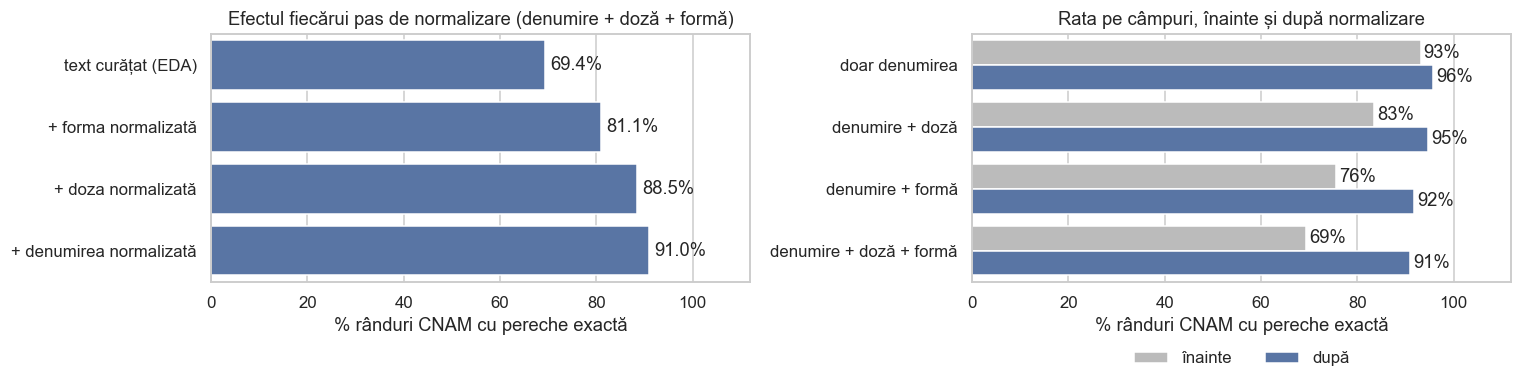

text curățat (EDA)         0.6940
+ forma normalizată        0.8108
+ doza normalizată         0.8851
+ denumirea normalizată    0.9100

                         înainte    după
doar denumirea            0.9312  0.9580
denumire + doză           0.8348  0.9474
denumire + formă          0.7563  0.9174
denumire + doză + formă   0.6940  0.9100


In [8]:
def match_rate(a, b, cols_a, cols_b=None):
    # proporția rândurilor din a care au în b un rând cu EXACT aceleași valori pe coloanele date
    cols_b = cols_b or cols_a
    ka = pd.Series(list(zip(*[a[x] for x in cols_a])))
    kb = set(zip(*[b[x] for x in cols_b]))
    return ka.isin(kb).mean()

# Versiunea „înainte”: textul curățat din pasul 2 (69% în EDA)
for d in (n, ro):
    for f in ["denumire", "doza", "forma"]:
        d[f + "_key"] = key_text(d[f])

# (a) contribuția fiecărui pas de normalizare, adăugat pe rând
pasi = pd.Series({
    "text curățat (EDA)":         match_rate(ro, n, ["denumire_key", "doza_key", "forma_key"]),
    "+ forma normalizată":        match_rate(ro, n, ["denumire_key", "doza_key", "forma_norm"]),
    "+ doza normalizată":         match_rate(ro, n, ["denumire_key", "doza_norm", "forma_norm"]),
    "+ denumirea normalizată":    match_rate(ro, n, ["denumire_norm", "doza_norm", "forma_norm"]),
})
# (b) ce câmp mai împiedică potrivirea, înainte și după
campuri = pd.DataFrame({
    "înainte": [match_rate(ro, n, c_) for c_ in (["denumire_key"], ["denumire_key", "doza_key"],
                                                   ["denumire_key", "forma_key"], ["denumire_key", "doza_key", "forma_key"])],
    "după":    [match_rate(ro, n, c_) for c_ in (["denumire_norm"], ["denumire_norm", "doza_norm"],
                                                   ["denumire_norm", "forma_norm"], ["denumire_norm", "doza_norm", "forma_norm"])],
}, index=["doar denumirea", "denumire + doză", "denumire + formă", "denumire + doză + formă"])

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
sns.barplot(x=pasi.values * 100, y=pasi.index, ax=axes[0], color="#4C72B0")
for i, v in enumerate(pasi.values): axes[0].text(v * 100 + 1, i, f"{v:.1%}", va="center")
axes[0].set_title("Efectul fiecărui pas de normalizare (denumire + doză + formă)")
long = campuri.reset_index(names="câmpuri").melt(id_vars="câmpuri", var_name="", value_name="rata")
sns.barplot(data=long.assign(rata=long.rata * 100), x="rata", y="câmpuri", hue="", ax=axes[1],
            palette=["#BBBBBB", "#4C72B0"])
for cont in axes[1].containers: axes[1].bar_label(cont, fmt="%.0f%%", padding=2)
axes[1].set_title("Rata pe câmpuri, înainte și după normalizare"); axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=False)
for ax in axes: ax.set_xlim(0, 112); ax.set_xlabel("% rânduri CNAM cu pereche exactă"); ax.set_ylabel("")
fig.tight_layout(); fig.savefig(FIG / "fig08_rata_potrivire_normalizare.png"); plt.show()
print(pasi.round(4).to_string()); print(); print(campuri.round(4).to_string())

**Ce am obținut.** Pornind de la 69,4% pe textul curățat, normalizarea formei ridică rata la 81,1%, normalizarea dozei o ridică la 88,5%, iar normalizarea denumirii o duce la 91,0%. Cea mai mare contribuție vine deci din formă, cu aproximativ 12 puncte procentuale, urmată de doză, cu aproximativ 7, și de denumire, cu aproximativ 2,5. Graficul din dreapta arată că, înainte de normalizare, rata scădea de la 93% pentru denumire singură la 69% pentru toate cele trei câmpuri, o pierdere de 24 de puncte. După normalizare, scade doar de la 95,8% la 91,0%, deci doza și forma nu mai sunt obstacolul principal.

**Constatare 4.** Normalizarea ridică rata de potrivire exactă a listei CNAM cu Nomenclatorul de la 69,4% la 91,0%. Forma farmaceutică aduce cel mai mare câștig, urmată de doză și de denumire, iar diferența dintre potrivirea după denumire și potrivirea după toate cele trei câmpuri scade de la 24 la aproximativ 5 puncte procentuale.

## 5. Controale: normalizarea nu strică și nu contopește

**Ce căutăm.** O normalizare prea agresivă ar putea crește rata de potrivire în mod fals, fie schimbând diferit același text în două surse, fie făcând identice produse diferite. Verificăm ambele riscuri. Pentru primul folosim perechile Catalog și Nomenclator legate prin cod, care descriu sigur același produs și trebuie să rămână identice. Pentru al doilea numărăm câte combinații de denumire, doză și formă din Nomenclator corespund mai multor coduri, înainte și după normalizare.

In [9]:
# Control 1: normalizarea NU trebuie să strice perechile corecte. Catalog și Nomenclator, legate prin cod,
# au același text; după normalizare trebuie să rămână identice (comparăm doar valorile prezente).
m = c.merge(n, on="cod", suffixes=("_c", "_n"))
for f in ["denumire_norm", "doza_norm", "forma_norm"]:
    both = m[f + "_c"].notna() & m[f + "_n"].notna()
    print(f"{f:14s}: identice în {(m.loc[both, f + '_c'] == m.loc[both, f + '_n']).mean():.2%} "
          f"din {both.sum()} perechi cu valoare prezentă")

# Control 2: normalizarea NU trebuie să contopească produse diferite. Câte chei (denumire, doză, formă)
# din Nomenclator corespund mai multor coduri, înainte și după?
for label, cols in [("înainte", ["denumire_key", "doza_key", "forma_key"]),
                    ("după", ["denumire_norm", "doza_norm", "forma_norm"])]:
    k = n.groupby(cols, dropna=False).cod.nunique()
    k_div = n.groupby(cols + ["divizare"], dropna=False).cod.nunique()
    print(f"{label:8s}: {len(k)} chei distincte; cu >1 cod: {(k > 1).sum()}; "
          f"cu >1 cod chiar și la aceeași divizare: {(k_div > 1).sum()}")

denumire_norm : identice în 100.00% din 3653 perechi cu valoare prezentă
doza_norm     : identice în 100.00% din 3427 perechi cu valoare prezentă
forma_norm    : identice în 100.00% din 3653 perechi cu valoare prezentă
înainte : 4048 chei distincte; cu >1 cod: 1326; cu >1 cod chiar și la aceeași divizare: 284
după    : 3997 chei distincte; cu >1 cod: 1346; cu >1 cod chiar și la aceeași divizare: 313


**Ce am obținut.** În perechile legate prin cod, denumirea, doza și forma normalizate sunt identice în 100% din cazuri, pentru 3.653 de perechi la denumire și formă și pentru 3.427 de perechi la doză, restul neavând doză în niciuna dintre surse. Normalizarea tratează deci identic același text, indiferent de sursă. Numărul de combinații distincte din Nomenclator scade de la 4.048 la 3.997. Multe combinații corespund mai multor coduri și înainte de normalizare, 1.326, pentru că același medicament este înregistrat în mai multe ambalaje. Dacă ținem cont și de divizare, combinațiile cu mai multe coduri cresc de la 284 la 313, deci normalizarea a unit doar 29 de combinații care erau scrise diferit. Aceste cazuri vor fi deosebite la potrivire prin divizare și deținător.

**Constatare 5.** Normalizarea nu strică perechile corecte, deoarece perechile Catalog și Nomenclator legate prin cod rămân identice în 100% din cazuri. Contopirile noi de produse sunt puține, 29 de combinații din aproximativ 4.000, deci creșterea ratei de potrivire nu este un efect artificial.

## 6. Ce rămâne nepotrivit

**Ce căutăm.** Vrem să știm de ce nu se potrivesc rândurile CNAM rămase. Pentru fiecare rând verificăm câmpurile în ordine și reținem primul care nu se regăsește în Nomenclator: mai întâi denumirea, apoi doza pentru acea denumire, apoi forma pentru acea denumire și doză.

In [10]:
# Ce rămâne nepotrivit și de ce: primul câmp care nu se regăsește în Nomenclator
names = set(n.denumire_norm.dropna())
name_dose = set(zip(n.denumire_norm, n.doza_norm))
full = set(zip(n.denumire_norm, n.doza_norm, n.forma_norm))
def motiv(r):
    if (r.denumire_norm, r.doza_norm, r.forma_norm) in full: return "potrivit"
    if r.denumire_norm not in names: return "denumirea nu există în Nomenclator"
    if (r.denumire_norm, r.doza_norm) not in name_dose: return "doza nu există pentru această denumire"
    return "forma nu există pentru această denumire și doză"
ro["motiv"] = ro.apply(motiv, axis=1)
print(ro.motiv.value_counts().to_string())
ro.loc[ro.motiv != "potrivit", ["denumire", "doza", "forma", "motiv"]].sample(12, random_state=1)

motiv
potrivit                                           1972
denumirea nu există în Nomenclator                   91
forma nu există pentru această denumire și doză      81
doza nu există pentru această denumire               23


,denumire,doza,forma,motiv
1489,Lordestin 5 mg,5 mg,comp. film.,denumirea nu există în Nomenclator
129,Azithromycin Lek®,500 mg,comprimate filmate,doza nu există pentru această denumire
155,"Emcor 2,5","2,5 mg",comprimate filmate,denumirea nu există în Nomenclator
453,Famotidin Sopharma,20 mg,comprimate filmate,denumirea nu există în Nomenclator
1875,Nimid®,100 mg,granule pentru suspensie orală,forma nu există pentru această denumire și doză
1642,"Flupamid SR 1,5 mg","1,5 mg",comprimate filmate cu eliberare prelungită,forma nu există pentru această denumire și doză
97,Amoksiklav® Quicktab® 875 mg/125 mg,875 mg + 125 mg,comprimate orodispersabile,forma nu există pentru această denumire și doză
228,Biotraxon,1 g,pulbere și solvent pentru soluţie injectabilă,forma nu există pentru această denumire și doză
1980,Rovaltro 20 mg,20 mg,comprimate filmate,denumirea nu există în Nomenclator
1274,Anastrozol,1 mg,comprimate,forma nu există pentru această denumire și doză


**Ce am obținut.** Din cele 2.167 de rânduri, 1.972 se potrivesc exact, iar 195, adică 9,0%, rămân nepotrivite. Pentru 91 dintre ele denumirea nu există ca atare în Nomenclator, pentru 23 denumirea există, dar nu cu această doză, iar pentru 81 denumirea și doza există, dar nu cu această formă. Exemplele arată de ce aceste cazuri nu pot fi rezolvate prin reguli. Unele denumiri sunt scrise altfel sau conțin un număr fără unitate, ca Emcor 2,5, altele diferă printr-un cuvânt, iar la unele produse, cum sunt Ceftriaxon sau Anastrozol, cele două surse descriu forma diferit. O regulă care ar forța aceste potriviri ar risca să lege produse diferite.

**Constatare 6.** După normalizare rămân nepotrivite 195 de rânduri CNAM, adică 9,0%, din cauza denumirii în 91 de cazuri, a formei în 81 și a dozei în 23. Acestea sunt diferențe care nu pot fi rezolvate prin reguli fără riscul unor potriviri false și reprezintă ținta potrivirii probabiliste, care va cântări similaritatea fiecărui câmp în loc să ceară egalitate exactă.

## 7. Efectul asupra grupurilor de echivalență

**Ce căutăm.** Grupurile de echivalență din analiza exploratorie au fost construite pe textul doar curățat, așa că unele echivalente reale nu ajungeau în același grup. Refacem calculul din Catalog cu cheia normalizată, exact ca în analiza exploratorie, și verificăm dacă rezultatele despre dispersia prețurilor se schimbă.

In [11]:
# Efectul asupra grupurilor de echivalență (Catalog), calculat ca în EDA, cu cheia veche și cu cea nouă
SOLIDE = r"comprimat|capsul|drajeu|supozitor|ovul|plic"
c["solid"] = key_text(c.forma).str.contains(SOLIDE, na=False)

def grupuri(key):
    g = (c.assign(grup=key).dropna(subset=["pret_unitate_mdl"]).groupby("grup")
          .agg(n=("cod", "size"), detinatori=("detinator", "nunique"), solid=("solid", "first"),
               pmin=("pret_unitate_mdl", "min"), pmax=("pret_unitate_mdl", "max")))
    return g[g.n >= 2].assign(raport=lambda d: d.pmax / d.pmin)

rez = {}
for label, key in [("cheia din EDA", equivalence_key(c)), ("cheia normalizată", equivalence_key_norm(c))]:
    g = grupuri(key); s = g[g.solid]
    rez[label] = {"grupuri (≥2 produse)": len(g), "produse în aceste grupuri": g.n.sum(),
                  "raport median": g.raport.median(), "% grupuri ≥ 2x": (g.raport >= 2).mean() * 100,
                  "grupuri solide": len(s), "raport median, solide": s.raport.median(),
                  "Spearman deținători–raport, solide": s[["detinatori", "raport"]].corr("spearman").iloc[0, 1]}
pd.DataFrame(rez).round(3)

,cheia din EDA,cheia normalizată
grupuri (≥2 produse),680.000,687.000
produse în aceste grupuri,2279.000,2357.000
raport median,1.337,1.340
% grupuri ≥ 2x,21.176,22.707
grupuri solide,358.000,359.000
"raport median, solide",1.308,1.303
"Spearman deținători–raport, solide",0.553,0.560


**Ce am obținut.** Cu cheia normalizată avem 687 de grupuri cu cel puțin două produse în loc de 680, iar numărul de produse din aceste grupuri crește de la 2.279 la 2.357, deci 78 de produse care înainte stăteau singure își găsesc acum echivalentele. Raportul median dintre prețul maxim și cel minim rămâne practic același, 1,34, iar proporția grupurilor cu o diferență de peste două ori crește ușor, de la 21,2% la 22,7%. La formele solide, mediana rămâne 1,30, iar corelația Spearman dintre numărul de deținători și dispersie trece de la 0,553 la 0,560. Prețurile formelor lichide sunt în continuare comparate pe flacon, iar normalizarea lor pe cantitatea de substanță rămâne pentru etapa de analiză a prețurilor.

**Constatare 7.** Constatările despre dispersia prețurilor din analiza exploratorie sunt stabile după normalizare. Raportul median rămâne 1,34, iar legătura dintre numărul de deținători și dispersie rămâne de aceeași intensitate, cu un coeficient Spearman de 0,56, în timp ce 78 de produse în plus intră în grupuri de comparație.

## 8. Rezumat și pașii următori

Normalizarea a adus aceeași informație, scrisă diferit în registrele AMDM și în lista CNAM, la o formă unică, prin reguli explicite și verificabile în fișierul src/normalize.py. Cel mai mare câștig a venit din dicționarul de abrevieri ale formei farmaceutice, urmat de analizorul de doze și de curățarea denumirilor. Rata de potrivire exactă a listei CNAM cu Nomenclatorul a crescut de la 69,4% la 91,0%, fără să strice perechile corecte și cu foarte puține contopiri noi, iar constatările despre dispersia prețurilor au rămas stabile.

Cele 195 de rânduri rămase nepotrivite sunt cazurile în care sursele diferă cu adevărat, prin greșeli de scriere, cuvinte în plus sau descrieri diferite ale formei. În pasul următor vom forma perechile candidate prin blocare după substanța activă, vom descrie fiecare pereche printr-un vector de comparații pe denumire, doză, formă și divizare, calculate pe coloanele normalizate, și vom estima modelul probabilist Fellegi Sunter prin algoritmul EM, pe care îl vom compara cu regresia logistică, cu un model SVM și cu o rețea neuronală.

**Ce căutăm.** Salvăm datele normalizate în folderul data/interim, astfel încât pasul de potrivire să pornească de aici fără să repete citirea, curățarea și normalizarea.

In [12]:
# Salvăm datele normalizate pentru pasul următor (blocare, comparare, potrivire probabilistă)
keep = lambda d: d.drop(columns=[x for x in d.columns if x.endswith("_key") or x in ("motiv", "solid")])
keep(n).to_csv(INTERIM / "nomenclator_norm.csv", index=False)
keep(c).to_csv(INTERIM / "catalog_norm.csv", index=False)
keep(ro).to_csv(INTERIM / "cnam_ro_norm.csv", index=False)
print("Salvat în", INTERIM, ":", sorted(p.name for p in INTERIM.glob("*_norm.csv")))

Salvat în /Users/oleseapopa/Desktop/UTM_M2/Proiect_SD/SD_utm/data/interim : ['catalog_norm.csv', 'cnam_ro_norm.csv', 'nomenclator_norm.csv']


**Ce am obținut.** Au fost salvate trei fișiere, nomenclator_norm.csv, catalog_norm.csv și cnam_ro_norm.csv, care conțin coloanele originale și cele trei coloane normalizate. 

**Ce căutăm.** Salvăm cifrele principale ale normalizării în secțiunea „normalizare” a fișierului data/processed/rezultate.json. Din acest fișier își ia cifrele dashboard-ul de prezentare, astfel încât, dacă pipeline-ul rulează pe alte date, dashboard-ul arată automat rezultatele noi.

In [13]:
from results import save                                      # rezultatele principale, pentru dashboard
rez_norm = save(ROOT / "data" / "processed" / "rezultate.json", "normalizare", {
    "pasi": pasi,                                             # rata potrivirii exacte după fiecare pas de normalizare
    "campuri": campuri,                                       # rata pe câmpuri, înainte și după normalizare
    "motive": ro.motiv.value_counts(),                        # de ce rămân rânduri CNAM nepotrivite
    "randuri": {"nomenclator": len(n), "catalog": len(c), "cnam_ro": len(ro)},
})
rez_norm["pasi"]

{'text curățat (EDA)': 0.694,
 '+ forma normalizată': 0.8108,
 '+ doza normalizată': 0.8851,
 '+ denumirea normalizată': 0.91}

**Ce am obținut.** Secțiunea „normalizare” conține rata potrivirii exacte după fiecare pas, de la 69,4% pe textul curățat la 91,0% după normalizarea denumirii, rata pe câmpuri înainte și după normalizare, motivele pentru care rămân rânduri nepotrivite și numărul de rânduri din fiecare sursă.